In [185]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd


In [186]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'n_cs_vs_K_parameter_swipe'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251216-102526'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [187]:
final_abundance_data = data['all_N_final']
final_resource_data = data['all_R_final']


In [188]:
final_abundance_matrix = np.zeros((args.N_cs, args.N_K_std, args.N_Csp, args.iterations, 4))
counter = 0
for i in range(args.N_cs):
    for j in range(args.N_K_std):
        for k in range(args.N_Csp):
            final_abundance_matrix[i,j,k,:,:] = final_abundance_data[counter]
            counter += 1
            

In [189]:
all_C = {f'C_{i}_{j}': data[f'C_{i}_{j}'] for i in range(final_abundance_matrix.shape[0]) for j in range(final_abundance_matrix.shape[1])}

In [190]:
richness_matrix = (final_abundance_matrix > 1e-6).sum(axis=4).mean(axis=3)
median_richness = np.median((final_abundance_matrix > 1e-6).sum(axis=4), axis=3)

# Make variable lists from args


In [191]:

n_cs_arr = np.linspace(args.cs_min, args.cs_max, num=args.N_cs, dtype=int, endpoint = True)
K_std_arr = np.linspace(args.K_std_min, args.K_std_max, num = args.N_K_std, endpoint = True)
c_arr = np.linspace(args.csp_min, args.csp_max, num = args.N_Csp, endpoint = True)


In [192]:
richness_matrix[-1,-1,:]

array([2.88, 3.3 , 3.34, 3.48, 3.6 , 3.4 ])

In [194]:
all_D = {f'D_{i}_{j}': data[f'D_{i}_{j}'] for i in range(final_abundance_matrix.shape[0]) for j in range(final_abundance_matrix.shape[1])}

In [195]:
for x in data.keys():
    if 'D_' in x:
        print(x)

D_0_0
D_0_1
D_0_2
D_0_3
D_0_4
D_0_5
D_0_6
D_0_7
D_0_8
D_0_9
D_0_10
D_0_11
D_0_12
D_0_13
D_0_14
D_0_15
D_0_16
D_0_17
D_0_18
D_0_19
D_0_20
D_0_21
D_0_22
D_0_23
D_0_24
D_0_25
D_0_26
D_0_27
D_0_28
D_0_29
D_0_30
D_0_31
D_0_32
D_0_33
D_0_34
D_0_35
D_0_36
D_0_37
D_0_38
D_0_39
D_0_40
D_0_41
D_0_42
D_0_43
D_0_44
D_0_45
D_0_46
D_0_47
D_0_48
D_0_49
D_1_0
D_1_1
D_1_2
D_1_3
D_1_4
D_1_5
D_1_6
D_1_7
D_1_8
D_1_9
D_1_10
D_1_11
D_1_12
D_1_13
D_1_14
D_1_15
D_1_16
D_1_17
D_1_18
D_1_19
D_1_20
D_1_21
D_1_22
D_1_23
D_1_24
D_1_25
D_1_26
D_1_27
D_1_28
D_1_29
D_1_30
D_1_31
D_1_32
D_1_33
D_1_34
D_1_35
D_1_36
D_1_37
D_1_38
D_1_39
D_1_40
D_1_41
D_1_42
D_1_43
D_1_44
D_1_45
D_1_46
D_1_47
D_1_48
D_1_49
D_2_0
D_2_1
D_2_2
D_2_3
D_2_4
D_2_5
D_2_6
D_2_7
D_2_8
D_2_9
D_2_10
D_2_11
D_2_12
D_2_13
D_2_14
D_2_15
D_2_16
D_2_17
D_2_18
D_2_19
D_2_20
D_2_21
D_2_22
D_2_23
D_2_24
D_2_25
D_2_26
D_2_27
D_2_28
D_2_29
D_2_30
D_2_31
D_2_32
D_2_33
D_2_34
D_2_35
D_2_36
D_2_37
D_2_38
D_2_39
D_2_40
D_2_41
D_2_42
D_2_43
D_2_44
D_2_45
D_2_46
D

In [ ]:
# plt.hist(logD, bins=50)

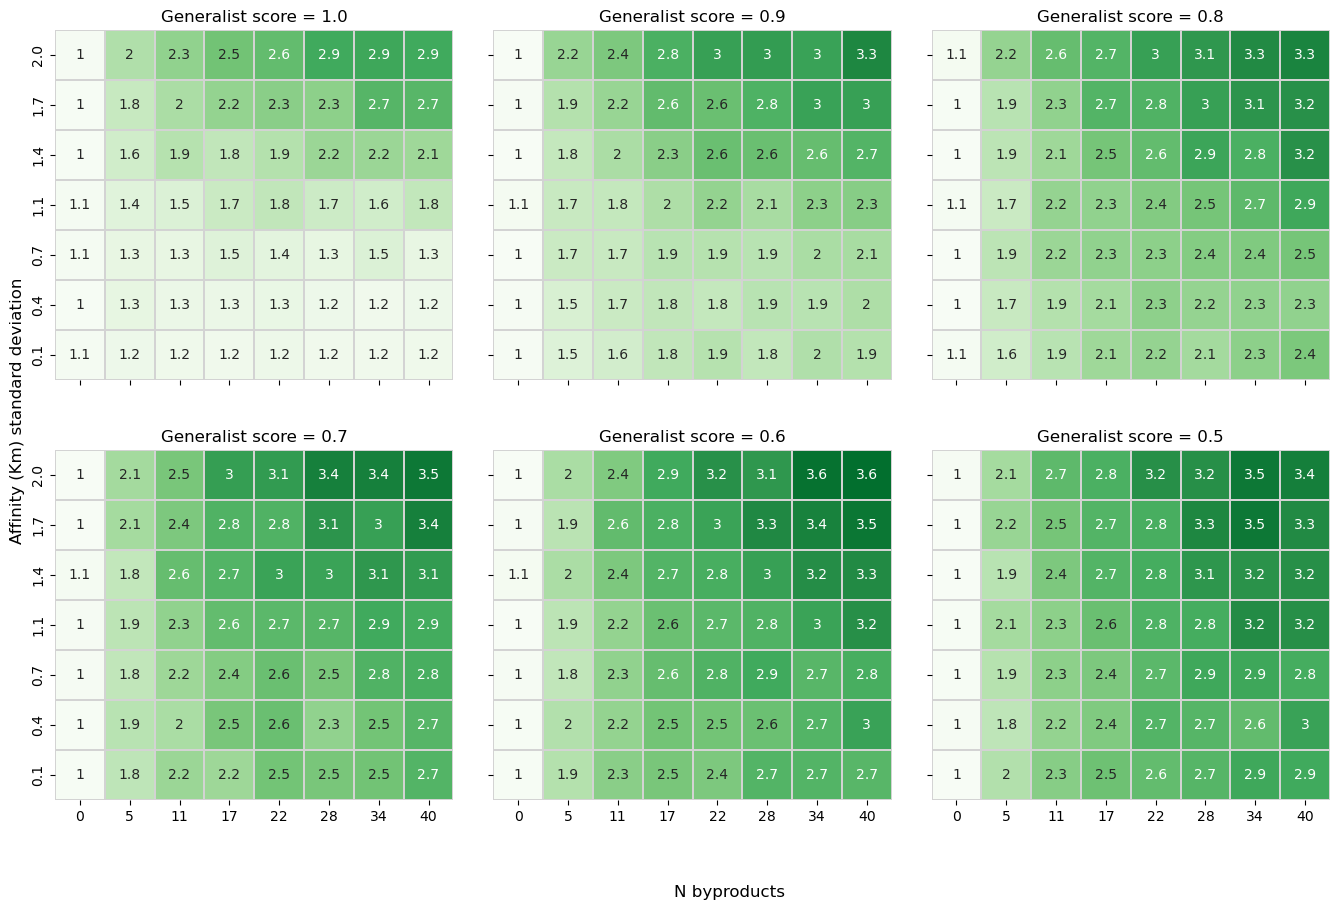

In [196]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(args.N_Csp):
    ax = axes[i]
    ax.set_title(f'Generalist score = {1 - c_arr[i]:.1f}')
    sns.heatmap(richness_matrix[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')

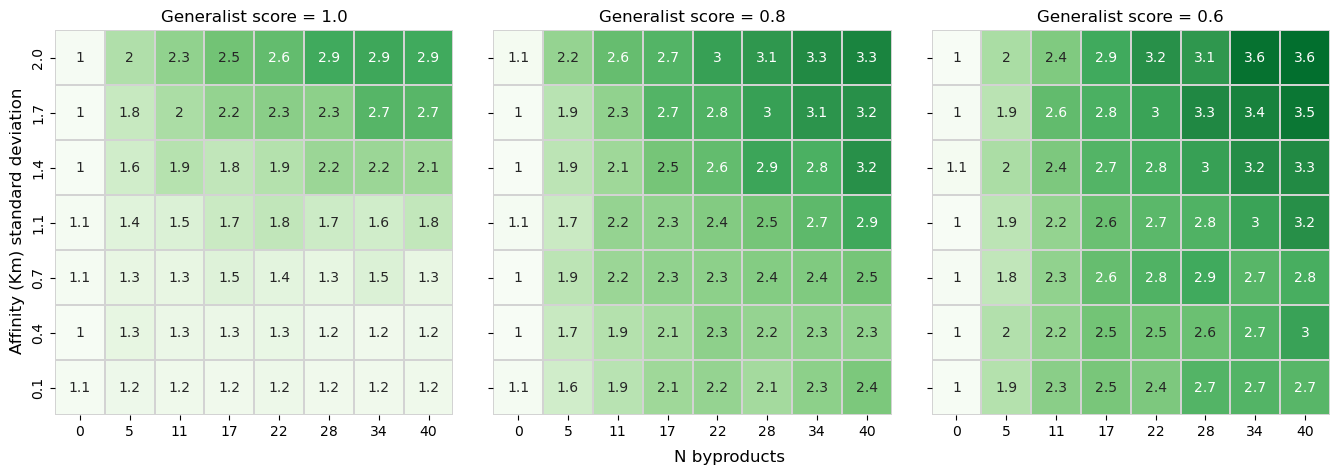

In [197]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
axes = axes.flatten()
for i,j in enumerate([0, 2, 4]):
    ax = axes[i]
    ax.set_title(f'Generalist score = {1 - c_arr[j]:.1f}')
    sns.heatmap(richness_matrix[:,::-1,j].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')
plt.savefig(figure_folder / f'20250826_richness_heatmap.pdf', bbox_inches='tight')

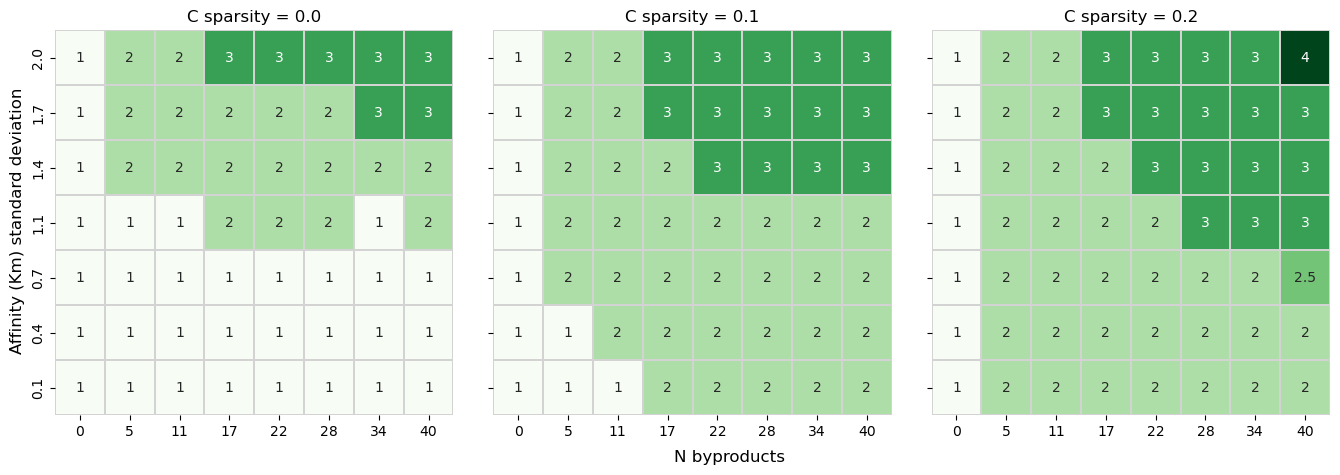

In [198]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for i in range(3):
    ax = axes[i]
    ax.set_title(f'C sparsity = {c_arr[i]:.1f}')
    sns.heatmap(median_richness[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')

Text(20.72222222222222, 0.5, 'C sparsity')

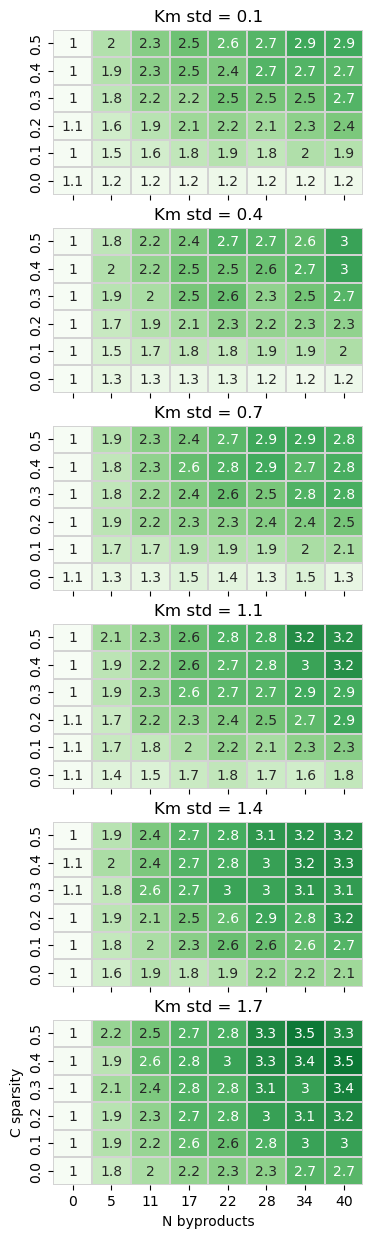

In [200]:
fig, axes = plt.subplots(6, 1, figsize=(4, 15), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(6):
    ax = axes[i]
    ax.set_title(f'Km std = {K_std_arr[i]:.1f}')
    sns.heatmap(richness_matrix[:,i,::-1].T, 
                yticklabels=[f'{x:.1f}' for x in c_arr][::-1],
                cmap='Greens',
                cbar = False,
                # cbar_kws={'label':'Mean richness'}, 
                # xticklabels = np.linspace(2, 30, 29, dtype=int)-1,
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
    plt.xlabel('N byproducts')
plt.ylabel('C sparsity')

# plt.title('Richness on single carbon source with 4 species community')

# Plot distributions

In [201]:
# Flatten the abundance matrix
flat = final_abundance_matrix.reshape(
    len(n_cs_arr) * len(K_std_arr) * len(c_arr) * final_abundance_matrix.shape[3], 
    final_abundance_matrix.shape[4]
)

# Create metadata for each row
metadata = []
for i, ncs in enumerate(n_cs_arr):
    for j, kstd in enumerate(K_std_arr):
        for k, csp in enumerate(c_arr):
            for l in range(final_abundance_matrix.shape[3]):  # iterations
                metadata.append((ncs, kstd, csp, l))

# Build DataFrame
abundance_df = pd.DataFrame(flat, columns=[f"species_{i+1}" for i in range(final_abundance_matrix.shape[4])])
abundance_df[['n_cs', 'K_std', 'c_sparsity', 'iteration']] = pd.DataFrame(metadata)

# Optional: set metadata as index
abundance_df.set_index(['n_cs', 'K_std', 'c_sparsity', 'iteration'], inplace=True)
abundance_df.reset_index(inplace=True)

In [202]:
abundance_df['Richness'] = (abundance_df[['species_1', 'species_2', 'species_3', 'species_4']] > 1e-6).sum(axis=1)

In [203]:
(abundance_df['Richness']==0).sum()

np.int64(24)

(0.0, 4.0)

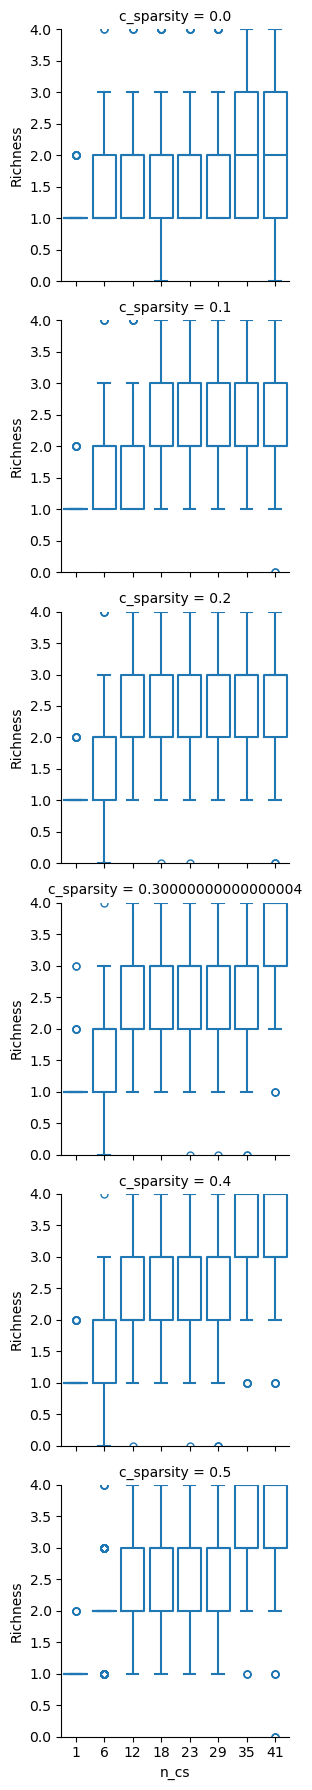

In [204]:

sns.catplot(data = abundance_df, 
            x = 'n_cs', y = 'Richness', 
            # col = 'K_std', 
            row = 'c_sparsity',
            kind = 'box',
            fill = False,
            # inner = None,
            height = 3, aspect = 1,
            sharey = True,
            sharex = True,
            # cut = 0
            )
plt.ylim(0, 4)

(0.0, 4.0)

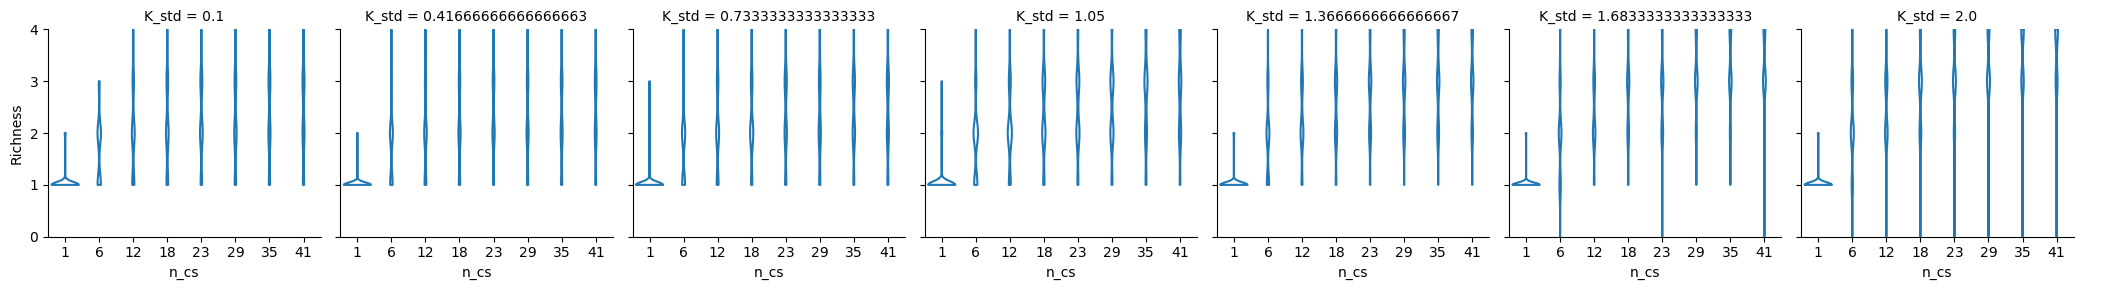

In [205]:

sns.catplot(data = abundance_df, 
            x = 'n_cs', y = 'Richness', 
            col = 'K_std', 
            # row = 'c_sparsity',
            kind = 'violin',
            fill = False,
            inner = None,
            height = 3, aspect = 1,
            sharey = True,
            sharex = True,
            cut = 0
            )
plt.ylim(0, 4)